# Assignment 3
2025 | IN6227 Data Mining | Roshani Ayu Pranasti | G2504973A

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

## Dataset Definition
I have prepared 1 dataset that is Introvert, Extrovert & Ambivert Classification. More about the dataset can be read on `README.md`.
1. **Introvert, Extrovert & Ambivert Classification**: `personality_dataset.csv`

## Exploratory Data Analysis

In [2]:
# Load dataset
personality_dataset = pd.read_csv("personality_dataset.csv")
display(personality_dataset)

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Ambivert,3.783857,4.345803,8.220063,6.297798,5.162622,5.702266,5.518356,3.420139,5.811565,...,8.521256,4.355973,6.454815,2.557365,6.949292,4.176390,5.649897,5.665498,5.252077,4.297520
19996,Introvert,2.621406,8.152097,2.954341,8.791467,2.670252,2.931244,5.855202,5.044124,6.244061,...,4.818308,2.631298,10.000000,3.697801,3.217559,3.638815,5.177155,5.106628,0.982214,5.873321
19997,Introvert,0.039689,8.277160,5.728101,7.790080,3.427897,0.708457,7.099321,5.784592,5.400400,...,3.318511,4.071008,9.974147,2.954407,5.427296,6.270830,3.793430,5.009167,3.810962,5.678412
19998,Extrovert,7.756725,3.956191,8.906972,3.793775,7.608467,6.292705,6.824980,5.653421,7.347820,...,7.156525,8.148780,3.840900,6.093418,7.814507,8.428745,8.736932,8.060841,8.161087,5.941793


In [3]:
print("Number of attributes in dataset:", personality_dataset.shape[1])
print("Number of data in dataset:", personality_dataset.shape[0], "\n")
personality_dataset.info()

Number of attributes in dataset: 30
Number of data in dataset: 20000 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  flo

In [4]:
print("Number of unknown or missing values in dataset:")
personality_dataset.isnull().sum()

Number of unknown or missing values in dataset:


personality_type            0
social_energy               0
alone_time_preference       0
talkativeness               0
deep_reflection             0
group_comfort               0
party_liking                0
listening_skill             0
empathy                     0
creativity                  0
organization                0
leadership                  0
risk_taking                 0
public_speaking_comfort     0
curiosity                   0
routine_preference          0
excitement_seeking          0
friendliness                0
emotional_stability         0
planning                    0
spontaneity                 0
adventurousness             0
reading_habit               0
sports_interest             0
online_social_usage         0
travel_desire               0
gadget_usage                0
work_style_collaborative    0
decision_speed              0
stress_handling             0
dtype: int64

## Standardize the Data
Whether to standardize the data prior to a PCA on the covariance matrix depends on the measurement scales of the original features. Since PCA yields a feature subspace that maximizes the variance along the axes, it makes sense to standardize the data, especially, if it was measured on different scales.

In [5]:
personality_dataset_features = personality_dataset.sample(900, random_state=120799).drop("personality_type", axis=1).dropna()
personality_dataset_std = StandardScaler().fit_transform(personality_dataset_features)
display(personality_dataset_std)

array([[-0.58641066, -1.04062107, -0.26768513, ..., -0.04557276,
         1.50075646,  0.71823746],
       [-0.41476364, -0.07837844, -0.34744539, ...,  0.10013379,
        -0.01532907, -0.3129072 ],
       [ 0.60250256, -0.94860837,  0.31950204, ...,  0.1526726 ,
         1.67329783, -0.52854247],
       ...,
       [-0.17966547,  0.16878826,  0.50795834, ...,  0.23784626,
         0.18506778, -1.14595964],
       [-0.88634652,  0.15775694, -0.15127404, ..., -0.75358585,
         0.62029172, -1.26841724],
       [-0.29014103,  1.59321856, -1.17412427, ..., -0.01185027,
        -1.72651032,  1.02935895]])

## Principal Component Analysis
PCA (Principal Component Analysis) is a technique used to reduce the number of features (dimensions) in a dataset. Its main goal is to simplify complex data while losing as little information as possible.

In [6]:
personality_dataset_pca = PCA(n_components=2).fit_transform(personality_dataset_std)
display(personality_dataset_pca)

array([[-0.11796386, -0.69628961],
       [-1.57001605, -2.03905901],
       [ 4.24675744,  0.05735798],
       ...,
       [-0.6366385 , -1.47772517],
       [-0.23165196, -1.39633009],
       [-4.60006368,  0.58341307]])

## Find the Optimal Number of Clusters (k)
The biggest challenge in K-Means is choosing the right number of clusters. The most popular method is the "Elbow Method". The logic is to run K-Means for a range of k values and plot the "inertia" (the sum of squared distances of samples to their closest cluster center). The "elbow" of the curve, where the rate of decrease sharply slows down, indicates the best k.

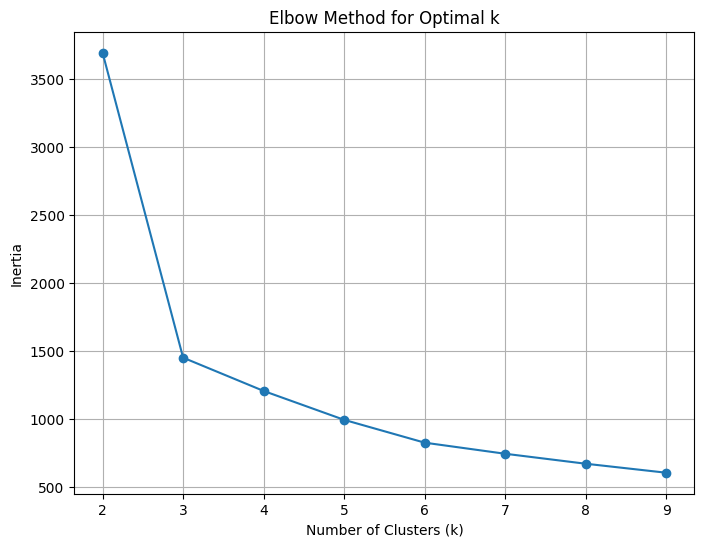

In [7]:
inertia = []
K_range = range(2,10) # Test k values from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, 
                    init='k-means++', 
                    n_init=10, 
                    random_state=42)
    kmeans.fit(personality_dataset_pca)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

As seen in the plot, the "elbow" is clearly at k=3.

## K-Means Clustering


In [8]:
# Helper function to plot a single K-Means iteration
def plot_kmeans_iteration(X, labels, centroids, title):
    """
    Helper function to plot a single plot of the K-Means algorithm.
    """
    # Plot the data points, colored by their cluster assignment
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='viridis', alpha=0.6)
    
    # Plot the centroids as large red 'X's
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='X', label='Centroids')
    
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

### K-Means++
The best and most common method for choosing initial centroids in K-Means is called K-Means++.

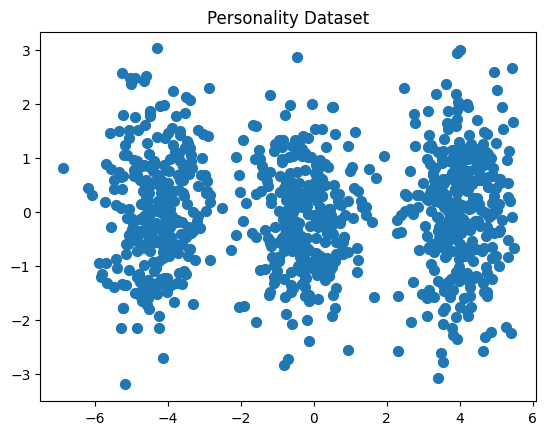

In [9]:
# Plot the data to see what we're working with
plt.scatter(personality_dataset_pca[:, 0], personality_dataset_pca[:, 1], s=50)
plt.title("Personality Dataset")
plt.show()

In [10]:
k = 3

# Create the final KMeans model with k=3
kmeans_final = KMeans(n_clusters=k, 
                      init='k-means++', 
                      n_init=10, 
                      random_state=42)

# Fit the model and predict the clusters
y_kmeans = kmeans_final.fit_predict(personality_dataset_pca)

# Get the cluster labels and the final centroid locations
labels = kmeans_final.labels_
centroids = kmeans_final.cluster_centers_

print("Best cluster labels (first 10 points):", labels[:10])
print("Best Centroid locations:\n", centroids)

Best cluster labels (first 10 points): [2 2 0 1 0 0 1 1 1 1]
Best Centroid locations:
 [[ 3.96519995  0.03035361]
 [-4.30064086  0.0565381 ]
 [-0.25724276 -0.08544479]]


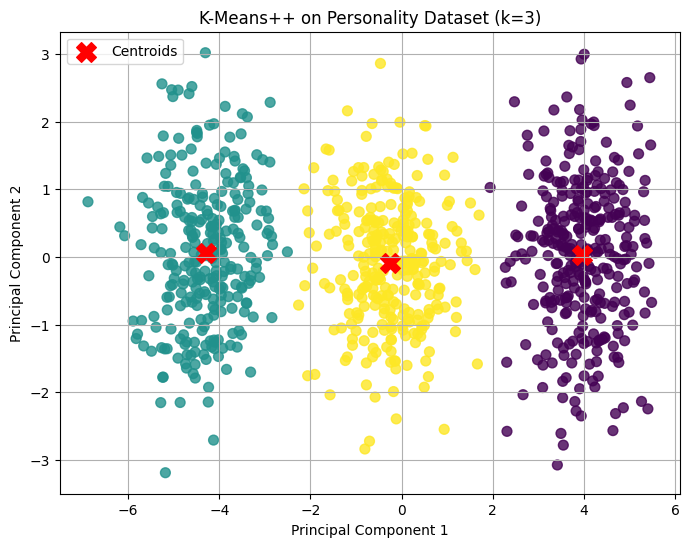

In [11]:
plt.figure(figsize=(8, 6))

# Plot the data points, colored by their assigned cluster
plt.scatter(personality_dataset_pca[:, 0], personality_dataset_pca[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.8)

# Plot the final centroids on top
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title('K-Means++ on Personality Dataset (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Good Initial Centroids

In [12]:
centroids_good = np.array([
    [1, 0], 
    [1, 1], 
    [1, -1]
])

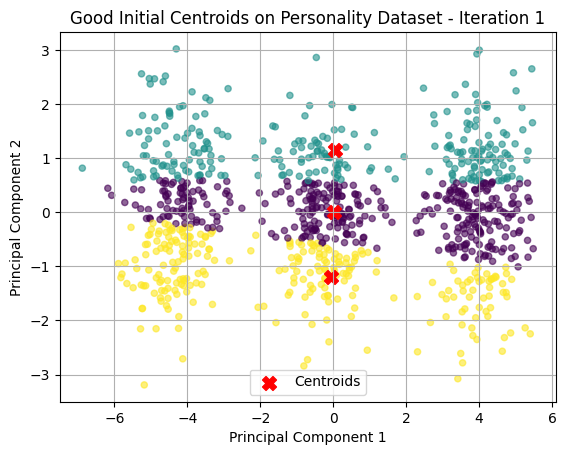

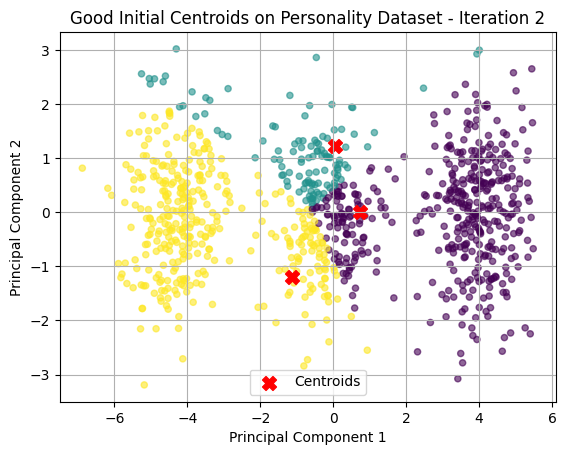

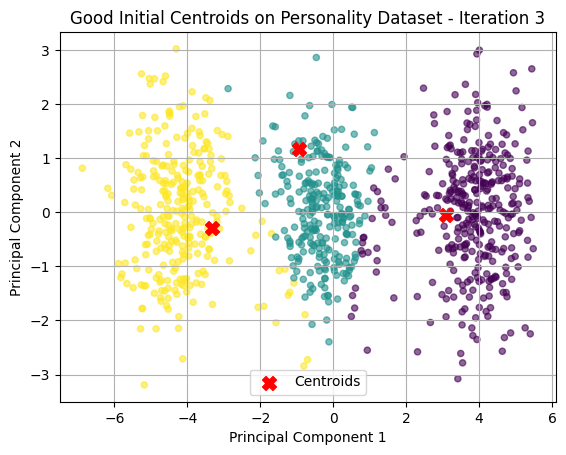

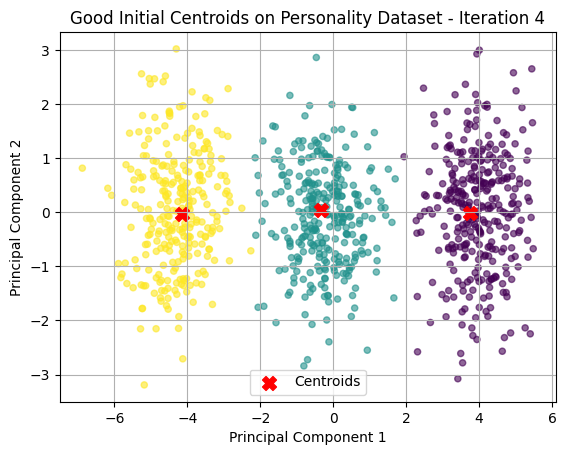

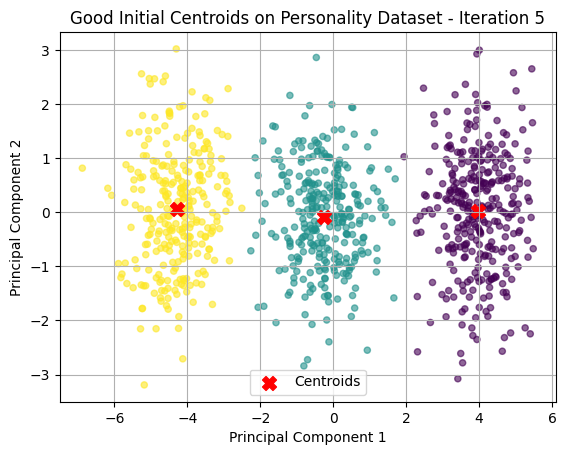

Cluster labels (first 10 points): [1 1 0 2 0 0 2 2 2 2]
Centroid locations:
 [[ 3.96519995  0.03035361]
 [-0.25052015 -0.0833417 ]
 [-4.29335492  0.05379272]]


In [13]:
for i in range(5):
    # Use our pre-defined 'centroids_good' as the starting point.
    # It will be updated by the algorithm in each loop.
    kmeans_good = KMeans(n_clusters=k,
                         init=centroids_good, 
                         n_init=1,        # Only run one time
                         max_iter=1,      # Only perform one iteration
                         random_state=42)
    
    kmeans_good.fit(personality_dataset_pca)
    
    # Get the new labels and centroids
    labels_good = kmeans_good.labels_
    centroids_good = kmeans_good.cluster_centers_ # Update centroids for the next loop
    
    # Plot this iteration
    plot_kmeans_iteration(personality_dataset_pca, labels_good, centroids_good, f'Good Initial Centroids on Personality Dataset - Iteration {i+1}')

    if i == 4:
        print("Cluster labels (first 10 points):", labels_good[:10])
        print("Centroid locations:\n", centroids_good)

### Bad Initial Centroids

In [14]:
# To demonstrate a "bad" choice, we will manually pick 3 centroids
# that are clustered together in the top-right corner of the data space.
data_min = personality_dataset_pca.min(axis=0) # Find the top-right
centroids_bad = np.array([
    data_min + 0.5,
    data_min + 0.6,
    data_min + 0.7
])

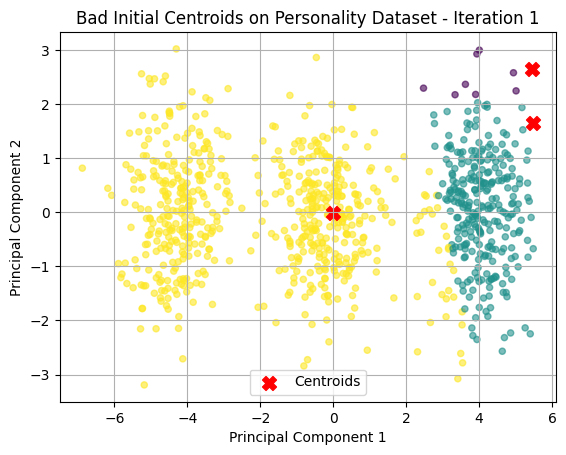

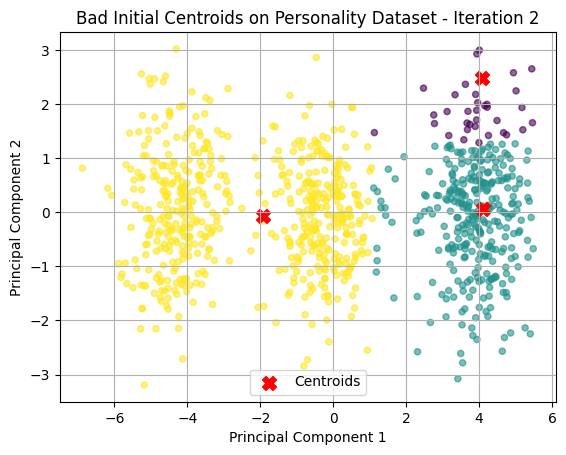

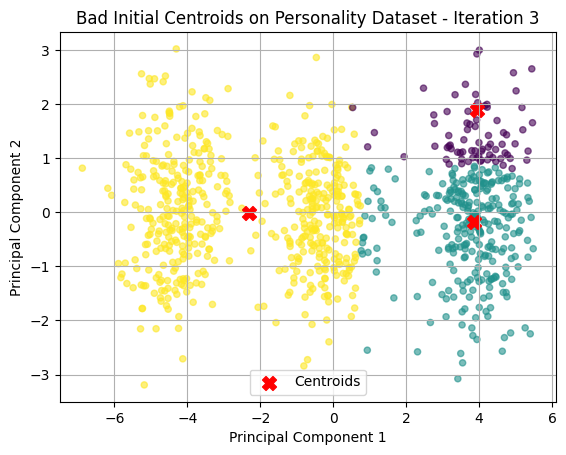

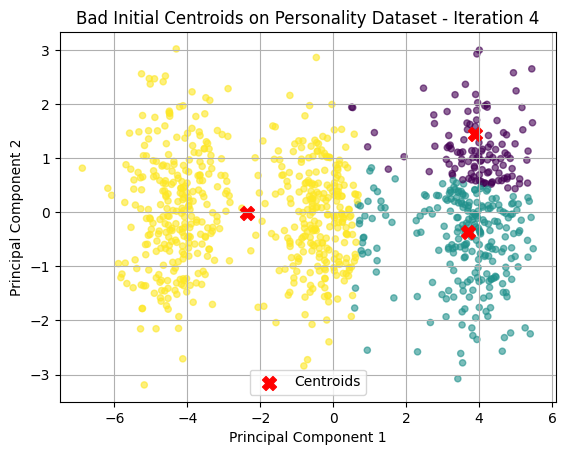

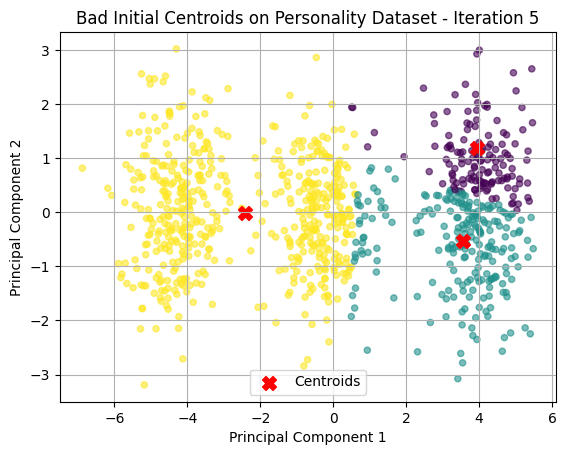

In [15]:
for i in range(5):
    # Use our pre-defined 'centroids_bad' as the starting point.
    # It will be updated by the algorithm in each loop.
    kmeans_bad = KMeans(n_clusters=k, 
                        init=centroids_bad, # Pass in the current centroids
                        n_init=1, 
                        max_iter=1,         # Only perform one iteration
                        random_state=42)
    
    kmeans_bad.fit(personality_dataset_pca)
    
    # Get the new labels and update the centroids for the next loop
    labels_bad = kmeans_bad.labels_
    centroids_bad = kmeans_bad.cluster_centers_
    
    # Plot this iteration
    plot_kmeans_iteration(personality_dataset_pca, labels_bad, centroids_bad, f'Bad Initial Centroids on Personality Dataset - Iteration {i+1}')

## Evaluate Resulted Clusters
After having labels, we can easily check the quality of the clusters using the Silhouette Score. Silhouette Score is a metric used to evaluate the quality of clustering results, like those from K-Means.

In [16]:
silhoutte_score = []

for n in K_range:
    clusterer = KMeans(n_clusters=n)
    preds = clusterer.fit_predict(personality_dataset_pca)
    centers = clusterer.cluster_centers_
    score = silhouette_score(personality_dataset_pca, preds)
    silhoutte_score.append(score)
    print("For n_clusters = {}, silhouette score is {})".format(n, score))

For n_clusters = 2, silhouette score is 0.5661943391090692)
For n_clusters = 3, silhouette score is 0.6121178197309292)
For n_clusters = 4, silhouette score is 0.5350028305730525)
For n_clusters = 5, silhouette score is 0.45366926102606997)
For n_clusters = 6, silhouette score is 0.42867184715323825)
For n_clusters = 7, silhouette score is 0.41218159927017)
For n_clusters = 8, silhouette score is 0.35108590156855246)
For n_clusters = 9, silhouette score is 0.33350368562938887)


In [17]:
# Calculate the silhouette score
score = silhouette_score(personality_dataset_pca, labels_good)

print(f"Silhouette Score for k=3: {score:.3f}")

Silhouette Score for k=3: 0.612


It is known that the best number of clusters (k) is 3 with silhouette score is 0.6121178197309292 matches the resulted labels.